In [1]:
using Images
include("../RayTracing.jl")

Main.RayTracing

# make albedo

In [78]:
function s_curve_midpoint(x, strength=2.0, midpoint=0.5)
    if x < midpoint
        # Scale x to [0, 0.5] range
        x_scaled = 0.5 * (x / midpoint)
        return midpoint * (2 * x_scaled)^strength
    else
        # Scale x to [0.5, 1] range
        # x_scaled = 0.5 + 0.5 * ((x - midpoint) / (1.0 - midpoint))
        # return midpoint + (1.0 - midpoint) * (1.0 - (2(1 - x_scaled))^strength)
        return 1.0
    end
end

s_curve_midpoint (generic function with 3 methods)

In [85]:
img = load(RayTracing.jmfp("/Users/johnmyslinski/Documents/PBRJ/ref/parchment/aged_parchment_1k.png"))

img = imresize(img, (500, 300))

img = Gray.(img)

# Apply power to gray values, then convert to RGB
img = s_curve_midpoint.(img, 10.0, 0.78)

img = clamp.(img, 0.0, 1.0)

img = RGB{Float64}.(img)
             
save("/Users/johnmyslinski/Documents/PBRJ/ref/parchment/parchment_1.jpg", img)

73028

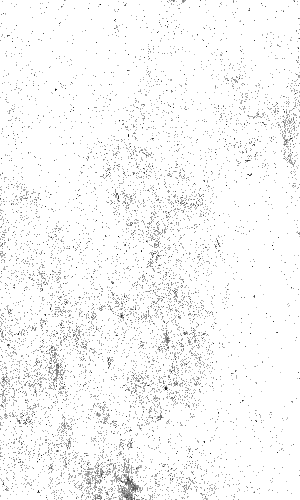

In [86]:
img

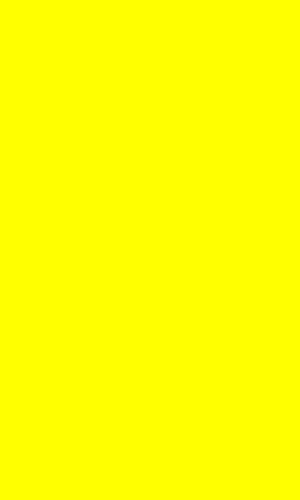

In [87]:
yellow = fill(RGB(1.0, 1.0, 0.0), 500, 300)

In [88]:
function multiply_rgb(c1::RGB, c2::RGB)
    return RGB(c1.r * c2.r, c1.g * c2.g, c1.b * c2.b)
end

multiply_rgb (generic function with 1 method)

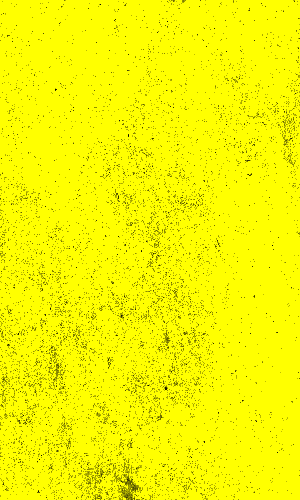

In [89]:
multiply_rgb.(img, yellow)